In [1]:
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import files
import io

In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Saving sample.xlsx to sample.xlsx
Rows: 1539
Columns: ['KEV #', 'CVE ID', 'Vendor', 'Product', 'Date Added', 'Description', 'CWE(s)', 'CAPEC(s)', 'ATT&CK ID(s)', 'ATT&CK Name(s)', 'Tactic(s)', 'Platform(s)', 'CPE(s)']


In [3]:
# Extract tactic, year, CWE, and platform from raw columns into clean usable fields
df['tactic'] = df['Tactic(s)'].fillna('Unknown').str.split('; ').str[0].str.strip()
df['year'] = pd.to_datetime(df['Date Added'], errors='coerce').dt.year.fillna(2022).astype(int)
df['cwe'] = df['CWE(s)'].astype(str).str.extract(r'(CWE-\d+)')[0].fillna('Unknown')

def encode_platform(text):
    text = str(text)
    if 'Windows' in text: return 'Windows'
    if 'Linux' in text: return 'Linux'
    if 'macOS' in text or 'iOS' in text: return 'Apple'
    if 'Network' in text: return 'Network'
    return 'Other'

df['platform'] = df['Platform(s)'].apply(encode_platform)

print("Data cleaned")
print(df[['CVE ID','tactic','platform','cwe','year']].head(5))

Data cleaned
           CVE ID             tactic platform      cwe  year
0  CVE-2021-22054     Initial Access  Windows  CWE-918  2026
1  CVE-2025-26399          Execution  Windows  CWE-502  2026
2   CVE-2026-1603    Defense Evasion  Windows  CWE-288  2026
3   CVE-2017-7921  Credential Access  Windows  CWE-287  2026
4  CVE-2021-22681  Credential Access  Windows  CWE-522  2026


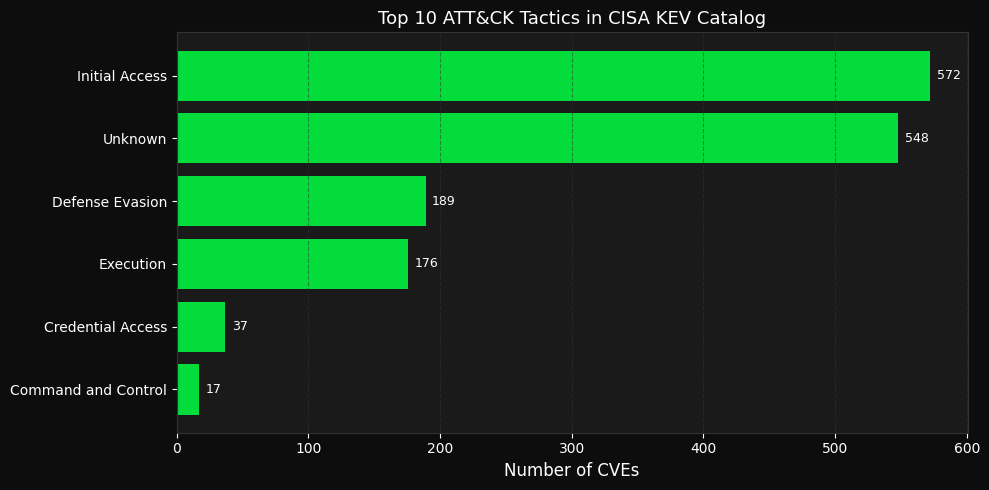

In [4]:
# --- Chart 1: top 10 ATT&CK tactics by CVE count across the full KEV dataset ---
tactic_counts = df['tactic'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

bars = ax.barh(tactic_counts.index[::-1], tactic_counts.values[::-1], color='#00FF41', alpha=0.85)
ax.set_xlabel('Number of CVEs', color='white', fontsize=12)
ax.set_title('Top 10 ATT&CK Tactics in CISA KEV Catalog', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

for bar, val in zip(bars, tactic_counts.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_tactics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

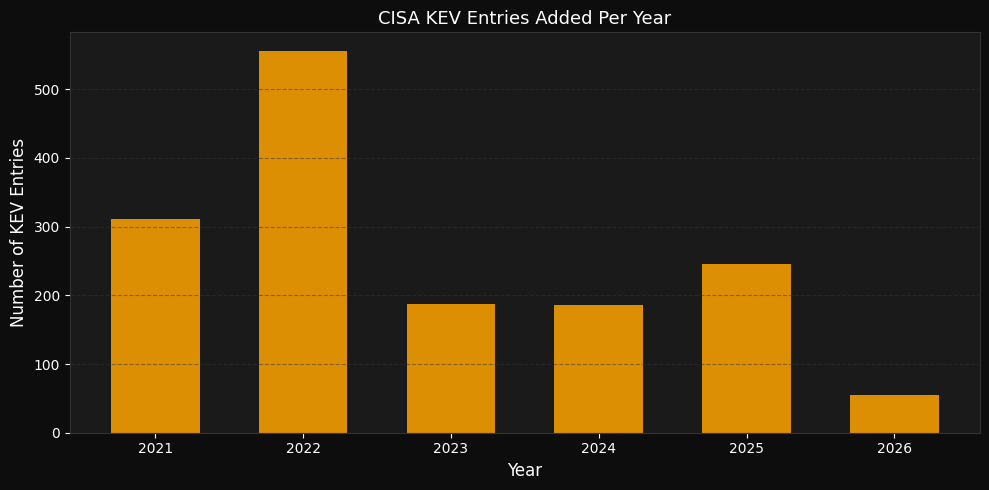

In [5]:
# --- Chart 2: number of KEV entries added per year to show catalog growth over time ---
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

ax.bar(year_counts.index, year_counts.values, color='#FFA500', alpha=0.85, width=0.6)
ax.set_xlabel('Year', color='white', fontsize=12)
ax.set_ylabel('Number of KEV Entries', color='white', fontsize=12)
ax.set_title('CISA KEV Entries Added Per Year', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
for spine in ax.spines.values(): spine.set_color('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('eda_years.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

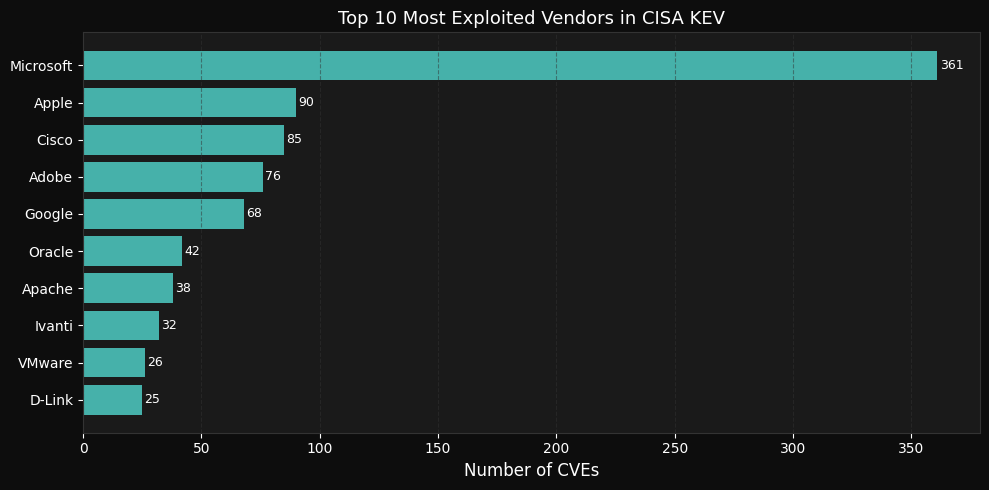

In [6]:
# --- Chart 3: top 10 most exploited vendors to identify who gets targeted most ---
vendor_counts = df['Vendor'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

bars = ax.barh(vendor_counts.index[::-1], vendor_counts.values[::-1], color='#4ECDC4', alpha=0.85)
ax.set_xlabel('Number of CVEs', color='white', fontsize=12)
ax.set_title('Top 10 Most Exploited Vendors in CISA KEV', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

for bar, val in zip(bars, vendor_counts.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_vendors.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

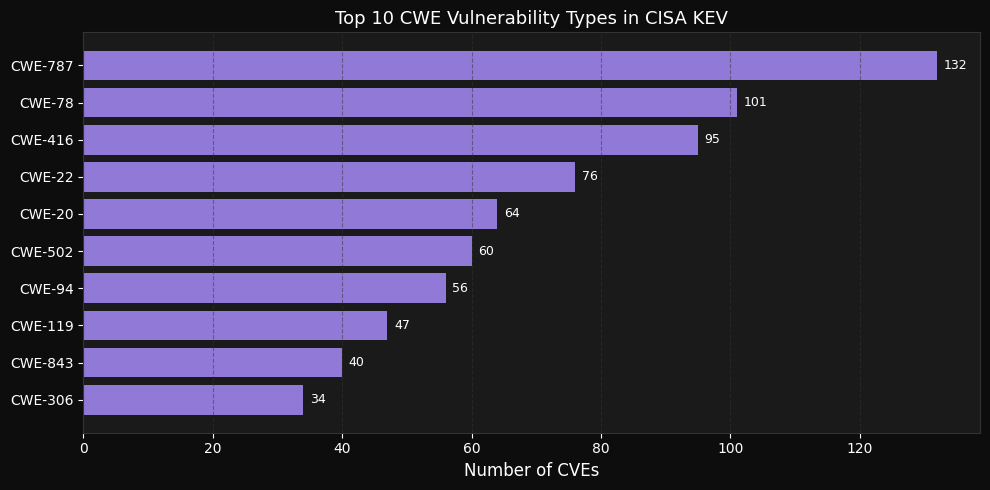

In [7]:
# --- Chart 4: Most common vulnerability types ---
cwe_counts = df[df['cwe'] != 'Unknown']['cwe'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

bars = ax.barh(cwe_counts.index[::-1], cwe_counts.values[::-1], color='#A78BFA', alpha=0.85)
ax.set_xlabel('Number of CVEs', color='white', fontsize=12)
ax.set_title('Top 10 CWE Vulnerability Types in CISA KEV', color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

for bar, val in zip(bars, cwe_counts.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('eda_cwes.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [8]:
print("=== DATASET SUMMARY ===")
print(f"Total KEV entries: {len(df)}")
print(f"Unique vendors: {df['Vendor'].nunique()}")
print(f"Unique CVEs: {df['CVE ID'].nunique()}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print(f"Most common tactic: {df['tactic'].value_counts().index[0]} ({df['tactic'].value_counts().iloc[0]} CVEs)")
print(f"Most exploited vendor: {df['Vendor'].value_counts().index[0]} ({df['Vendor'].value_counts().iloc[0]} CVEs)")
print(f"Most common platform: {df['platform'].value_counts().index[0]} ({df['platform'].value_counts().iloc[0]} CVEs)")
print(f"Most common CWE: {df[df['cwe']!='Unknown']['cwe'].value_counts().index[0]}")

=== DATASET SUMMARY ===
Total KEV entries: 1539
Unique vendors: 254
Unique CVEs: 1539
Year range: 2021 – 2026
Most common tactic: Initial Access (572 CVEs)
Most exploited vendor: Microsoft (361 CVEs)
Most common platform: Windows (991 CVEs)
Most common CWE: CWE-787
